# Plots (2D)

Two independent sections:
1. **Demonstrations** from `assets/demonstrations/demo_*.csv`
2. **Produced files** from `examples/gmm_mu.csv` / `examples/kmp_mu.csv` (after `./inference`)

| `DEMO_NAME` | File |
|---|---|
| `bottle_neck` | `assets/demonstrations/demo_bottle_neck.csv` |
| `synthetic` | `assets/demonstrations/demo_synthetic.csv` |
| `time_traj` | `assets/demonstrations/demo_time_traj.csv` |

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))

from util import REPO_ROOT, T_MAX, load_demo_csv

DEMO_NAME = "bottle_neck"
EXAMPLES_DIR = REPO_ROOT / "examples"
# T_MAX = 1.0 — shared with util / inference.cpp (demo times normalized to [0, 1])


## 1. Demonstrations

Source: `assets/demonstrations/demo_{DEMO_NAME}.csv`

In [ ]:
demos = load_demo_csv(DEMO_NAME)
print(f"{DEMO_NAME}: {len(demos)} trajectories")
for i, d in enumerate(demos):
    print(
        f"  [{i}] n={len(d['t'])}  "
        f"y0=[{d['y'][:, 0].min():.3f}, {d['y'][:, 0].max():.3f}]  "
        f"y1=[{d['y'][:, 1].min():.3f}, {d['y'][:, 1].max():.3f}]  "
        f"t=[{d['t'].min():.3f}, {d['t'].max():.3f}]"
    )

bottle_neck: 9 trajectories
  [0] n=113  y0=[0.181, 0.480]  y1=[0.095, 0.965]  t=[0.000, 1.000]
  [1] n=95  y0=[0.466, 0.824]  y1=[0.109, 0.985]  t=[0.000, 1.000]
  [2] n=79  y0=[0.340, 0.492]  y1=[0.105, 0.963]  t=[0.000, 1.000]
  [3] n=60  y0=[0.463, 0.624]  y1=[0.116, 0.959]  t=[0.000, 1.000]
  [4] n=46  y0=[0.464, 0.513]  y1=[0.106, 0.981]  t=[0.000, 1.000]
  [5] n=49  y0=[0.453, 0.740]  y1=[0.103, 0.975]  t=[0.000, 1.000]
  [6] n=48  y0=[0.258, 0.496]  y1=[0.103, 0.953]  t=[0.000, 1.000]
  [7] n=52  y0=[0.461, 0.564]  y1=[0.112, 1.002]  t=[0.000, 1.000]
  [8] n=44  y0=[0.214, 0.470]  y1=[0.107, 0.967]  t=[0.000, 1.000]


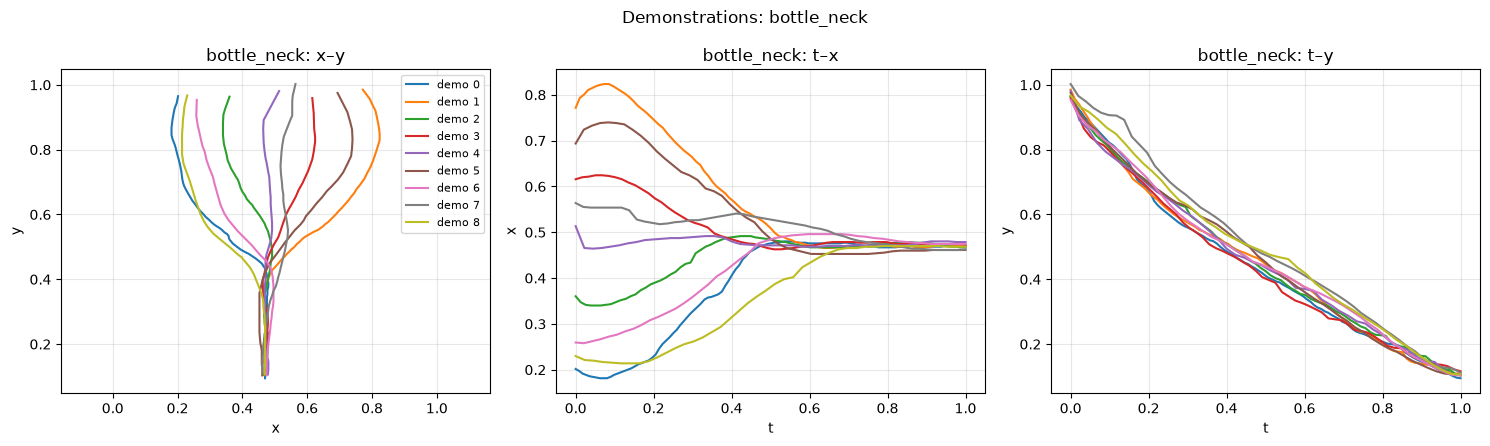

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax_xy, ax_tx, ax_ty = axes

for i, d in enumerate(demos):
    label = f"demo {i}"
    ax_xy.plot(d["y"][:, 0], d["y"][:, 1], linewidth=1.5, label=label)
    ax_tx.plot(d["t"], d["y"][:, 0], linewidth=1.5, label=label)
    ax_ty.plot(d["t"], d["y"][:, 1], linewidth=1.5, label=label)

ax_xy.set_title(f"{DEMO_NAME}: x–y")
ax_xy.set_xlabel("x")
ax_xy.set_ylabel("y")
ax_xy.set_aspect("equal", adjustable="datalim")
ax_xy.grid(True, alpha=0.3)
ax_xy.legend(fontsize=8)

ax_tx.set_title(f"{DEMO_NAME}: t–x")
ax_tx.set_xlabel("t")
ax_tx.set_ylabel("x")
ax_tx.grid(True, alpha=0.3)

ax_ty.set_title(f"{DEMO_NAME}: t–y")
ax_ty.set_xlabel("t")
ax_ty.set_ylabel("y")
ax_ty.grid(True, alpha=0.3)

fig.suptitle(f"Demonstrations: {DEMO_NAME}")
fig.tight_layout()
plt.show()

## 2. Produced files (GMR / KMP)

Source: `examples/gmm_mu.csv`, `examples/kmp_mu.csv` (no header; columns `x,y`).
Time axis: `linspace(0, T_MAX, N)` to match `inference.cpp`.

Run from `build/`: `./inference`

In [ ]:
gmm_mu_path = EXAMPLES_DIR / "gmm_mu.csv"
kmp_mu_path = EXAMPLES_DIR / "kmp_mu.csv"

gmm_mu = np.loadtxt(gmm_mu_path, delimiter=",")
kmp_mu = np.loadtxt(kmp_mu_path, delimiter=",")
if gmm_mu.ndim == 1:
    gmm_mu = gmm_mu.reshape(1, -1)
if kmp_mu.ndim == 1:
    kmp_mu = kmp_mu.reshape(1, -1)

t_gmm = np.linspace(0.0, T_MAX, len(gmm_mu))
t_kmp = np.linspace(0.0, T_MAX, len(kmp_mu))

print(f"gmm_mu {gmm_mu.shape} from {gmm_mu_path}")
print(f"kmp_mu {kmp_mu.shape} from {kmp_mu_path}")

gmm_mu (500, 2) from /home/abhi/kgrl/lc-ns-kmp/examples/gmm_mu.csv
kmp_mu (500, 2) from /home/abhi/kgrl/lc-ns-kmp/examples/kmp_mu.csv


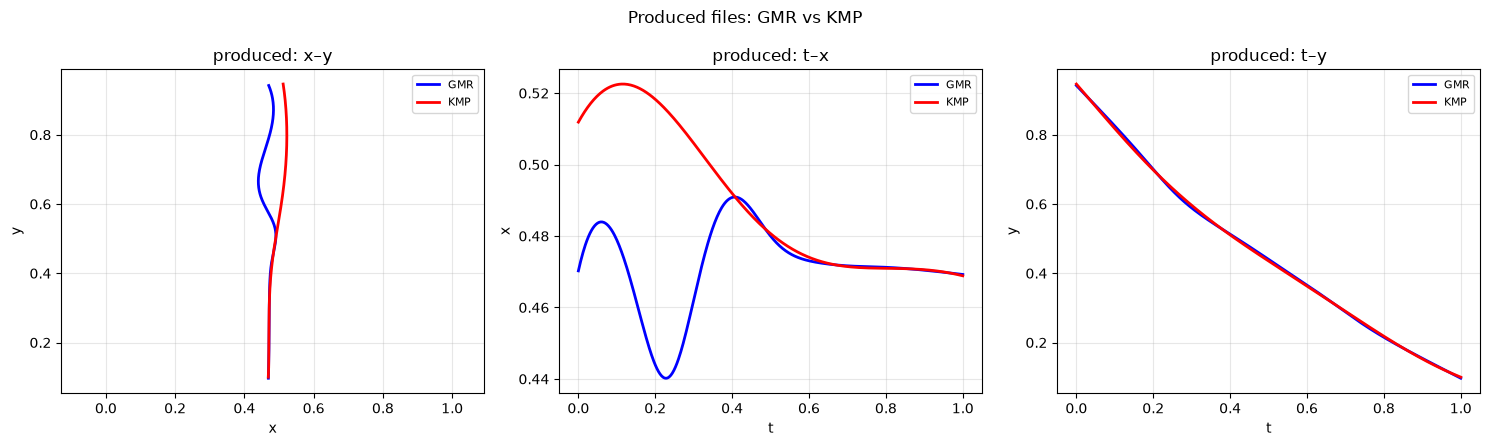

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax_xy, ax_tx, ax_ty = axes

ax_xy.plot(gmm_mu[:, 0], gmm_mu[:, 1], "b-", linewidth=2.0, label="GMR")
ax_xy.plot(kmp_mu[:, 0], kmp_mu[:, 1], "r-", linewidth=2.0, label="KMP")
ax_tx.plot(t_gmm, gmm_mu[:, 0], "b-", linewidth=2.0, label="GMR")
ax_tx.plot(t_kmp, kmp_mu[:, 0], "r-", linewidth=2.0, label="KMP")
ax_ty.plot(t_gmm, gmm_mu[:, 1], "b-", linewidth=2.0, label="GMR")
ax_ty.plot(t_kmp, kmp_mu[:, 1], "r-", linewidth=2.0, label="KMP")

ax_xy.set_title("produced: x–y")
ax_xy.set_xlabel("x")
ax_xy.set_ylabel("y")
ax_xy.set_aspect("equal", adjustable="datalim")
ax_xy.legend(fontsize=8)
ax_xy.grid(True, alpha=0.3)

ax_tx.set_title("produced: t–x")
ax_tx.set_xlabel("t")
ax_tx.set_ylabel("x")
ax_tx.legend(fontsize=8)
ax_tx.grid(True, alpha=0.3)

ax_ty.set_title("produced: t–y")
ax_ty.set_xlabel("t")
ax_ty.set_ylabel("y")
ax_ty.legend(fontsize=8)
ax_ty.grid(True, alpha=0.3)

fig.suptitle("Produced files: GMR vs KMP")
fig.tight_layout()
plt.show()